In [1]:
# =========================
# 📦 LIBRERÍAS PRINCIPALES
# =========================
import pandas as pd
import numpy as np

# =========================
# 📊 VISUALIZACIÓN
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# estilo visual
plt.style.use('default')
sns.set_theme()

# =========================
# ⚙️ CONFIGURACIÓN
# =========================
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
df = pd.read_csv('../data/costos_constructivos_jhconstrucciones.csv')

df.head()

,proyecto,nombre_proyecto,tipo_proyecto,fase,actividad,material,unidad_medida,cantidad_material,costo_unitario,costo_material,dias_trabajados,duracion_estimada,duracion_real,retraso_dias,costo_mano_obra,costo_estimado,costo_real,diferencia_costo,porcentaje_desviacion,ciudad,clima,estado_costo,fecha_inicio,fecha_fin,offset_inicio,duracion_calculada
0,8,Mall Gran Avenida,Comercial,Instalaciones,Eléctrica,Punto eléctrico,Punto,12,120000,1440000,11,11,11,0,120000,1320000,1320000,0,0.00,Bogotá,Nublado,En presupuesto,2025-01-06,2025-01-16,5,10
1,7,Edificio Corporativo Torre Norte,Comercial,Instalaciones,Acueducto,Punto agua,Punto,19,140000,2660000,17,19,17,-2,120000,2280000,2040000,240000,10.53,Bogotá,Soleado,Ahorro,2025-01-09,2025-02-22,8,44
2,5,Residencial Jardines del Sur,Residencial,Acabados,Cielorraso,Drywall,Lámina,12,40000,480000,13,13,13,0,100000,1300000,1300000,0,0.00,Bogotá,Nublado,En presupuesto,2025-01-04,2025-03-06,3,61
3,7,Edificio Corporativo Torre Norte,Comercial,Acabados,Enchape,Cerámica,m2,19,50000,950000,15,17,15,-2,105000,1785000,1575000,210000,11.76,Bogotá,Soleado,Ahorro,2025-01-04,2025-02-15,3,42
4,3,Residencial Altos del Norte,Residencial,Estructura,Vaciado,Concreto,m3,8,350000,2800000,25,32,25,-7,130000,4160000,3250000,910000,21.88,Bogotá,Soleado,Ahorro,2025-01-07,2025-02-01,6,25


In [4]:
# fechas
df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'])
df['fecha_fin'] = pd.to_datetime(df['fecha_fin'])

# columna MES (clave para filtros)
df['mes'] = df['fecha_inicio'].dt.to_period('M').astype(str)

# costo total
df['costo_total'] = df['costo_material'] + df['costo_mano_obra']

# validaciones
df = df.drop_duplicates()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4921 entries, 0 to 4920
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   proyecto               4921 non-null   int64         
 1   nombre_proyecto        4921 non-null   str           
 2   tipo_proyecto          4921 non-null   str           
 3   fase                   4921 non-null   str           
 4   actividad              4921 non-null   str           
 5   material               4921 non-null   str           
 6   unidad_medida          4921 non-null   str           
 7   cantidad_material      4921 non-null   int64         
 8   costo_unitario         4921 non-null   int64         
 9   costo_material         4921 non-null   int64         
 10  dias_trabajados        4921 non-null   int64         
 11  duracion_estimada      4921 non-null   int64         
 12  duracion_real          4921 non-null   int64         
 13  retraso_dias  

In [7]:
kpis = {
    "Costo Total": df['costo_total'].sum(),
    "Costo Real Total": df['costo_real'].sum(),
    "Desviación Promedio (%)": df['porcentaje_desviacion'].mean(),
    "Retraso Promedio (días)": df['retraso_dias'].mean(),
    "Proyecto Más Costoso": df.groupby('nombre_proyecto')['costo_total'].sum().idxmax()
}

kpis_df = pd.DataFrame(list(kpis.items()), columns=['KPI', 'Valor'])
kpis_df.to_csv('../data/processed/kpis.csv', index=False)

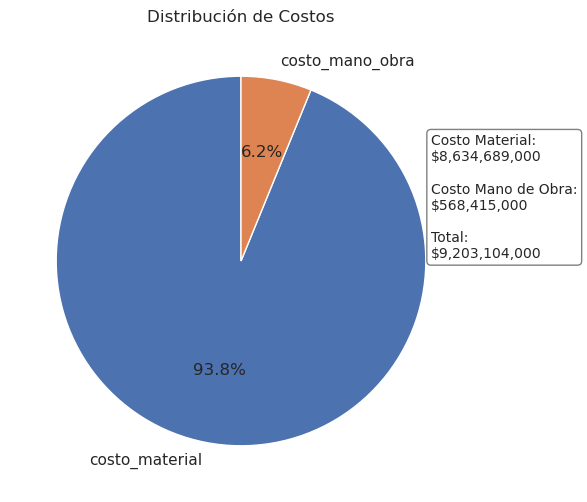

In [11]:
import matplotlib.pyplot as plt

# =========================
# 📊 DATOS
# =========================
costos = df[['costo_material','costo_mano_obra']].sum()

material = costos['costo_material']
mano_obra = costos['costo_mano_obra']
total = material + mano_obra

# =========================
# 📈 GRÁFICA
# =========================
plt.figure(figsize=(8,6))

costos.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribución de Costos")
plt.ylabel('')

# =========================
# 🧾 CUADRO DE RESUMEN (PRO 🔥)
# =========================
texto = (
    f"Costo Material:\n${material:,.0f}\n\n"
    f"Costo Mano de Obra:\n${mano_obra:,.0f}\n\n"
    f"Total:\n${total:,.0f}"
)

plt.gcf().text(
    0.75, 0.5,  # posición (derecha)
    texto,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round')
)

# =========================
# 💾 GUARDAR
# =========================
plt.savefig('../imagenes/distribucion_costos_pro.png', bbox_inches='tight')

plt.show()

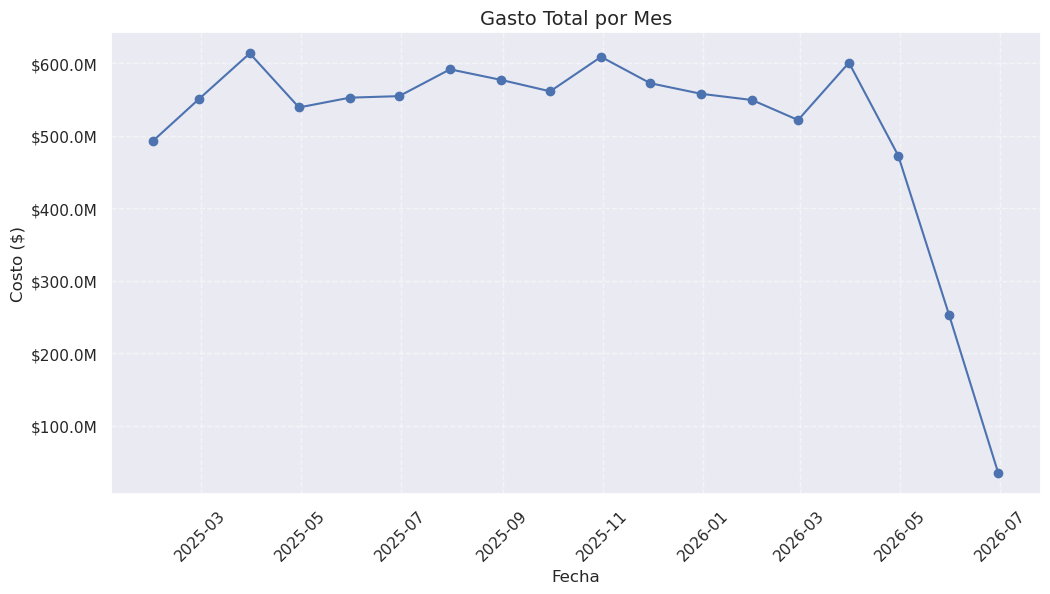

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# 📅 AGRUPAR POR MES (ORDENADO)
# =========================
df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'])

costos_mes = (
    df
    .set_index('fecha_inicio')
    .resample('ME')['costo_total']
    .sum()
)

# =========================
# 📊 GRÁFICA
# =========================
plt.figure(figsize=(12,6))  # 👉 más larga (lo que querías)

plt.plot(
    costos_mes.index,
    costos_mes.values,
    marker='o'
)

plt.title("Gasto Total por Mes", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Costo ($)")

# =========================
# 💰 FORMATO PROFESIONAL EJE Y
# =========================
def formato_millones(x, pos):
    return f'${x/1_000_000:.1f}M'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(formato_millones))

# =========================
# 📅 MEJORAR EJE X
# =========================
plt.xticks(rotation=45)

# =========================
# 📊 GRID (PRO)
# =========================
plt.grid(True, linestyle='--', alpha=0.5)

# =========================
# 💾 GUARDAR
# =========================
plt.savefig('../imagenes/costos_mes_pro.png', bbox_inches='tight')

plt.show()

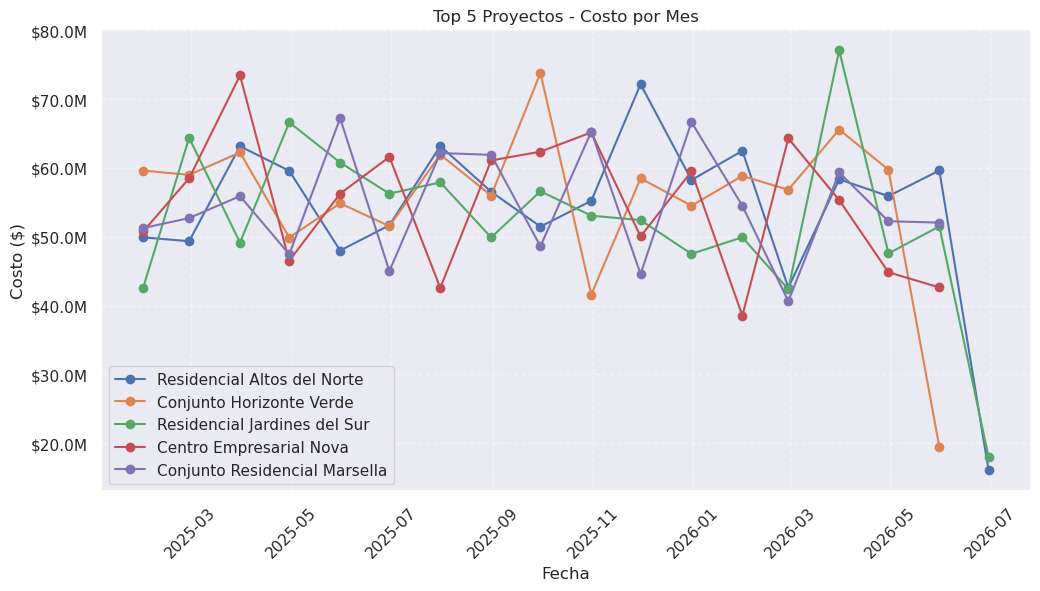

In [17]:
# Top 5 proyectos por costo total
top_proyectos = (
    df.groupby('nombre_proyecto')['costo_total']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'])

df_filtrado = df[df['nombre_proyecto'].isin(top_proyectos)]

costos_mes_proyecto = (
    df_filtrado
    .set_index('fecha_inicio')
    .groupby('nombre_proyecto')
    .resample('ME')['costo_total']
    .sum()
    .reset_index()
)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

for proyecto in top_proyectos:
    data = costos_mes_proyecto[costos_mes_proyecto['nombre_proyecto'] == proyecto]
    
    plt.plot(
        data['fecha_inicio'],
        data['costo_total'],
        marker='o',
        label=proyecto
    )

plt.title("Top 5 Proyectos - Costo por Mes")
plt.xlabel("Fecha")
plt.ylabel("Costo ($)")

# formato millones
def formato_millones(x, pos):
    return f'${x/1_000_000:.1f}M'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(formato_millones))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('../imagenes/top_proyectos_mes.png', bbox_inches='tight')

plt.show()

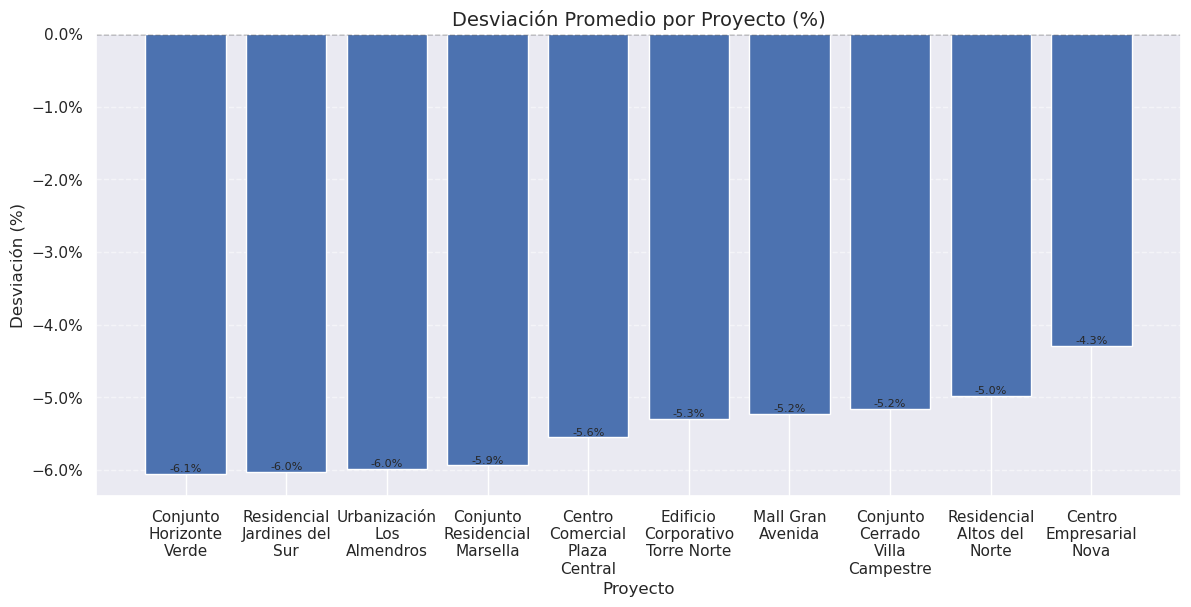

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import textwrap

# =========================
# 📊 AGRUPAR DATOS
# =========================
desv = df.groupby('nombre_proyecto')['porcentaje_desviacion'].mean().sort_values()

# =========================
# ✂️ AJUSTAR TEXTO (SALTO DE LÍNEA)
# =========================
labels = ['\n'.join(textwrap.wrap(label, 12)) for label in desv.index]

# =========================
# 📈 GRÁFICA
# =========================
plt.figure(figsize=(14,6))  # más ancha como querías

bars = plt.bar(labels, desv.values)

plt.title("Desviación Promedio por Proyecto (%)", fontsize=14)
plt.xlabel("Proyecto")
plt.ylabel("Desviación (%)")

# =========================
# 💰 FORMATO PORCENTAJE
# =========================
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter())

# =========================
# 📏 LÍNEA DE REFERENCIA (CLAVE 🔥)
# =========================
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# =========================
# 📊 GRID
# =========================
plt.grid(axis='y', linestyle='--', alpha=0.5)

# =========================
# 🔄 ROTACIÓN CONTROLADA
# =========================
plt.xticks(rotation=0)

# =========================
# 🧾 VALORES ENCIMA DE BARRAS
# =========================
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval:.1f}%',
             ha='center', va='bottom', fontsize=8)

# =========================
# 💾 GUARDAR
# =========================
plt.savefig('../imagenes/desviacion_pro.png', bbox_inches='tight')

plt.show()

📊 Interpretación de la Desviación por Proyecto

Se observa una tendencia generalizada a desviaciones positivas en todos los proyectos analizados, lo que indica que, en promedio, los costos reales han superado los costos estimados.

El rango de desviación se encuentra aproximadamente entre 4.3% y 6.0%, lo que sugiere que, aunque los sobrecostos no son extremadamente altos, sí son consistentes en todos los proyectos.

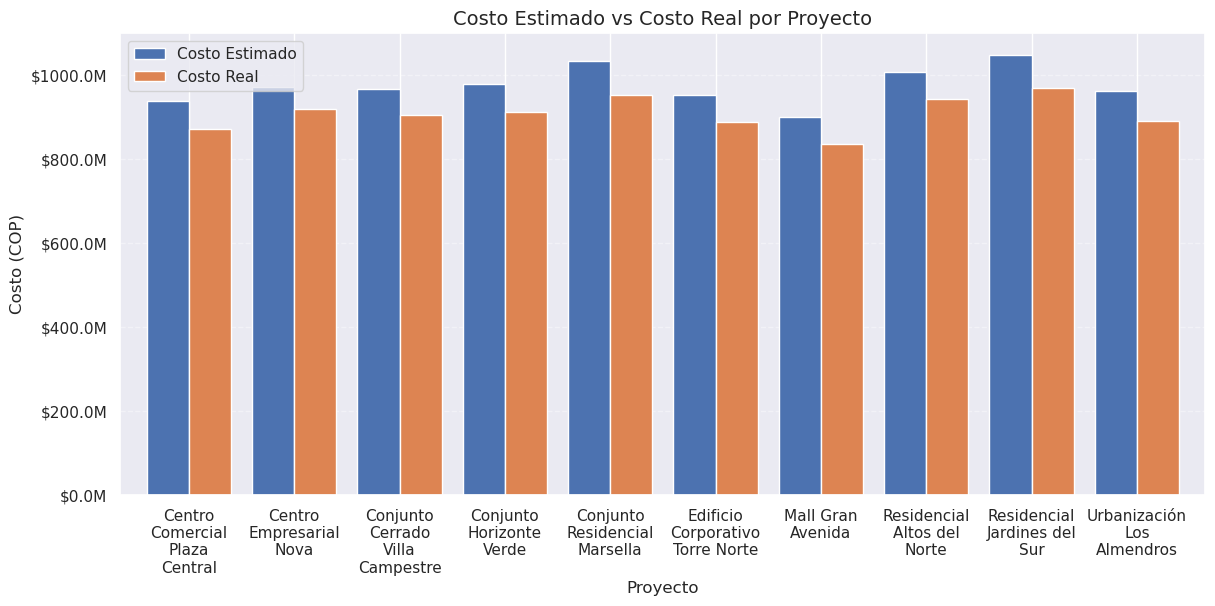

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import textwrap

# =========================
# 📊 AGRUPAR DATOS
# =========================
df_group = df.groupby('nombre_proyecto')[['costo_estimado','costo_real']].sum()

# =========================
# ✂️ MODIFICAR LABELS DESDE EL DATAFRAME
# =========================
df_group.index = ['\n'.join(textwrap.wrap(label, 12)) for label in df_group.index]

# =========================
# 📈 GRÁFICA
# =========================
ax = df_group.plot(
    kind='bar',
    figsize=(14,6),
    width=0.8
)

plt.title("Costo Estimado vs Costo Real por Proyecto", fontsize=14)
plt.xlabel("Proyecto")
plt.ylabel("Costo (COP)")

# =========================
# 💰 FORMATO MILLONES
# =========================
def formato_millones(x, pos):
    return f'${x/1_000_000:.1f}M'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(formato_millones))

# =========================
# 🔤 ASEGURAR HORIZONTAL
# =========================
plt.xticks(rotation=0)

# =========================
# 📊 GRID
# =========================
plt.grid(axis='y', linestyle='--', alpha=0.4)

# =========================
# 🎯 LEYENDA
# =========================
plt.legend(["Costo Estimado", "Costo Real"])

# =========================
# 💾 GUARDAR
# =========================
plt.savefig('../imagenes/estimado_vs_real_pro.png', bbox_inches='tight')

plt.show()

In [31]:
# =========================
# 📊 CORREGIR DESVIACIÓN
# =========================
df['porcentaje_desviacion'] = (
    (df['costo_real'] - df['costo_estimado']) 
    / df['costo_estimado']
) * 100

In [32]:
df[['costo_estimado','costo_real','porcentaje_desviacion']].head()

,costo_estimado,costo_real,porcentaje_desviacion
0,1320000,1320000,0.00
1,2280000,2040000,-10.53
2,1300000,1300000,0.00
3,1785000,1575000,-11.76
4,4160000,3250000,-21.88


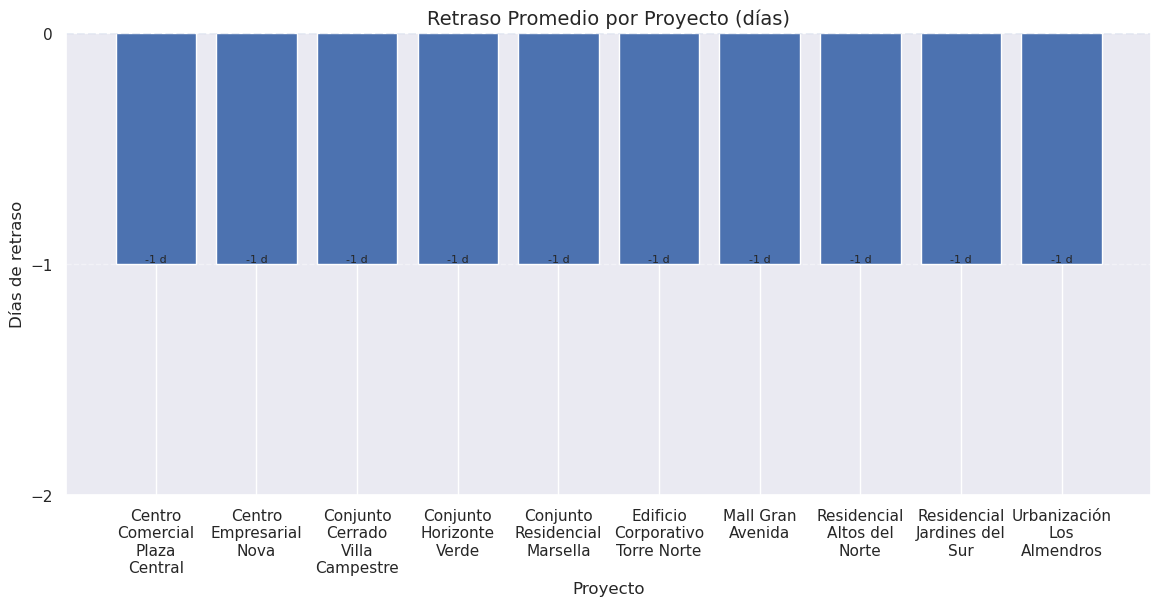

In [37]:
import matplotlib.pyplot as plt
import textwrap
import numpy as np

# =========================
# 📊 AGRUPAR DATOS
# =========================
retraso = df.groupby('nombre_proyecto')['retraso_dias'].mean()

# =========================
# 🔢 REDONDEAR A DÍAS ENTEROS
# =========================
retraso = retraso.round().astype(int)

# =========================
# ✂️ AJUSTAR NOMBRES
# =========================
retraso.index = ['\n'.join(textwrap.wrap(label, 12)) for label in retraso.index]

# =========================
# 📈 GRÁFICA
# =========================
plt.figure(figsize=(14,6))
bars = plt.bar(retraso.index, retraso.values)

plt.title("Retraso Promedio por Proyecto (días)", fontsize=14)
plt.xlabel("Proyecto")
plt.ylabel("Días de retraso")

# =========================
# 🔥 EJE Y SOLO ENTEROS
# =========================
plt.yticks(
    np.arange(min(retraso.values)-1, max(retraso.values)+2, 1)
)

# =========================
# 📏 LÍNEA EN CERO
# =========================
plt.axhline(0, linestyle='--')

# =========================
# 🔄 X LIMPIO
# =========================
plt.xticks(rotation=0)

# =========================
# 📊 GRID
# =========================
plt.grid(axis='y', linestyle='--', alpha=0.4)

# =========================
# 🧾 VALORES ENCIMA
# =========================
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{yval} d',
        ha='center',
        va='bottom',
        fontsize=8
    )


# =========================
# 💾 GUARDAR
# =========================
plt.savefig('../imagenes/retraso_proyectos_pro.png', bbox_inches='tight')

plt.show()

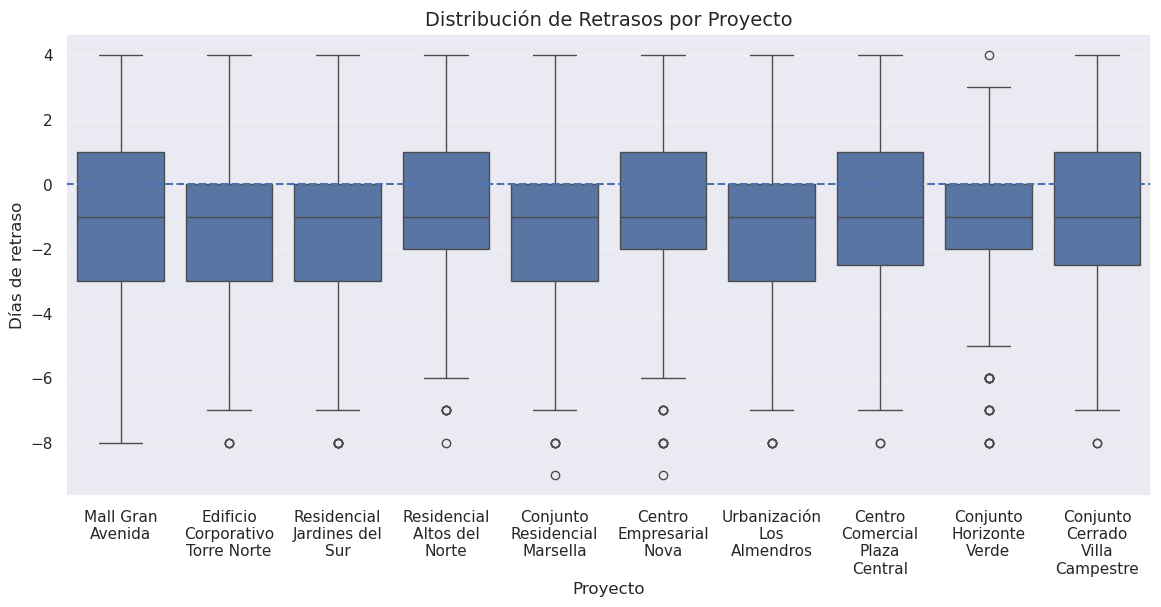

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

# =========================
# ✂️ AJUSTAR NOMBRES
# =========================
df['proyecto_label'] = df['nombre_proyecto'].apply(
    lambda x: '\n'.join(textwrap.wrap(x, 12))
)

# =========================
# 📊 BOXPLOT
# =========================
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='proyecto_label',
    y='retraso_dias'
)

# =========================
# 📏 LÍNEA EN CERO
# =========================
plt.axhline(0, linestyle='--')

# =========================
# 🏷️ TÍTULOS
# =========================
plt.title("Distribución de Retrasos por Proyecto", fontsize=14)
plt.xlabel("Proyecto")
plt.ylabel("Días de retraso")

plt.xticks(rotation=0)

# =========================
# 📊 GRID
# =========================
plt.grid(axis='y', linestyle='--', alpha=0.4)

# =========================
# 💾 GUARDAR
# =========================
plt.savefig('../imagenes/boxplot_retrasos.png', bbox_inches='tight')

plt.show()

“El boxplot permite identificar la variabilidad en los retrasos por proyecto, evidenciando no solo el promedio sino también la dispersión y posibles valores atípicos.”

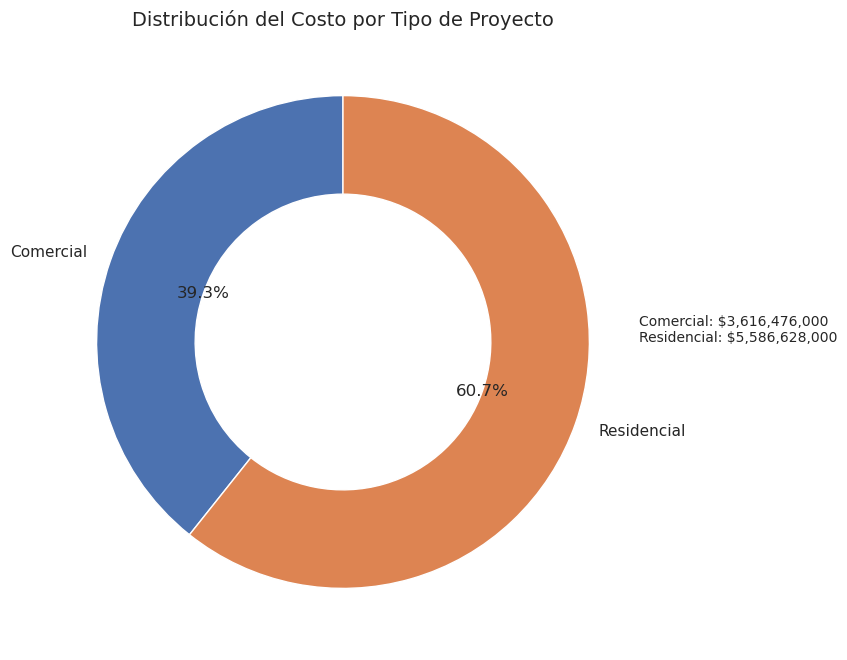

In [41]:
import matplotlib.pyplot as plt

# =========================
# 📊 AGRUPAR DATOS
# =========================
tipo = df.groupby('tipo_proyecto')['costo_total'].sum()

# =========================
# 📈 GRÁFICA DONUT
# =========================
plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    tipo,
    labels=tipo.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)  # 👈 esto crea el efecto donut
)

# =========================
# 🏷️ TÍTULO
# =========================
plt.title("Distribución del Costo por Tipo de Proyecto", fontsize=14)

# =========================
# 💰 TEXTO CON VALORES (ESQUINA)
# =========================
texto = "\n".join([
    f"{idx}: ${val:,.0f}" for idx, val in tipo.items()
])

plt.text(
    1.2, 0,  # posición a la derecha
    texto,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.6)
)

# =========================
# 💾 GUARDAR
# =========================
plt.savefig('../imagenes/costo_tipo_donut.png', bbox_inches='tight')

plt.show()

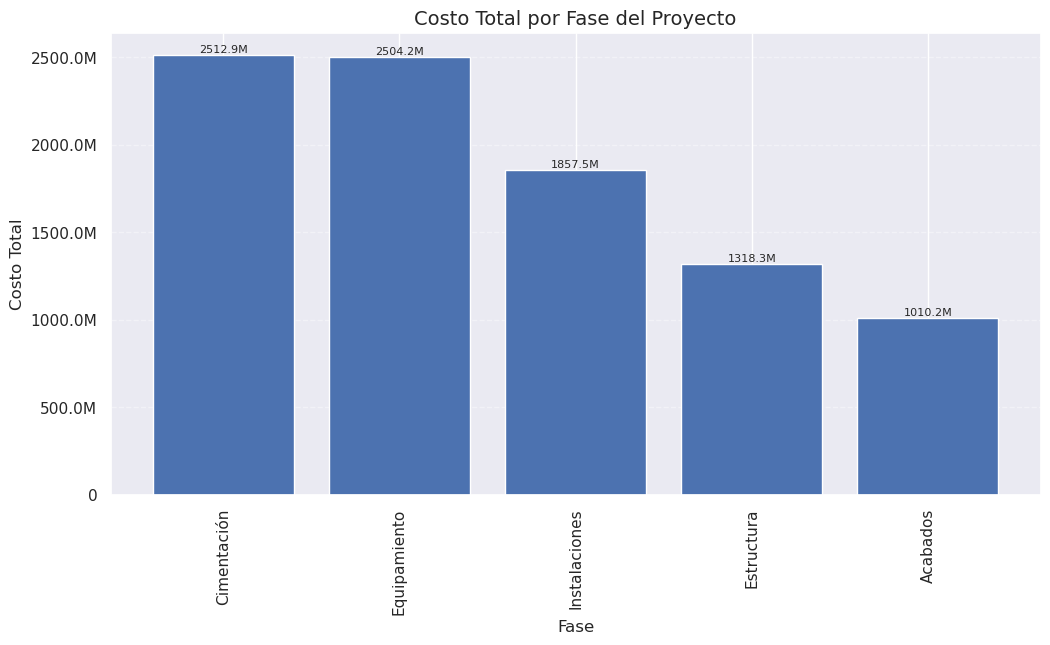

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# 📊 AGRUPAR POR FASE
# =========================
fases = (
    df.groupby('fase')['costo_total']
    .sum()
    .sort_values(ascending=False)
)

# =========================
# 📈 GRÁFICA
# =========================
plt.figure(figsize=(12,6))

bars = plt.bar(fases.index, fases.values)

plt.title("Costo Total por Fase del Proyecto", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Costo Total")

# =========================
# 🔄 NOMBRES VERTICALES
# =========================
plt.xticks(rotation=90)

# =========================
# 💰 FORMATO EJE Y (MILLONES)
# =========================
def formato_millones(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    else:
        return f'{x:.0f}'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(formato_millones))

# =========================
# 📊 GRID
# =========================
plt.grid(axis='y', linestyle='--', alpha=0.4)

# =========================
# 🧾 VALORES ENCIMA
# =========================
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        formato_millones(yval, None),
        ha='center',
        va='bottom',
        fontsize=8
    )

# =========================
# 💾 GUARDAR
# =========================
plt.savefig('../imagenes/costo_fases.png', bbox_inches='tight')

plt.show()

In [46]:
df['fase'].unique()

<StringArray>
['Instalaciones', 'Acabados', 'Estructura', 'Cimentación', 'Equipamiento']
Length: 5, dtype: str